<a href="https://colab.research.google.com/github/eduardozurek/ia/blob/main/_007_aprendizaje_supervisado/_006_07_KNN_Categoricas_Distancias_Binarias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KNN con características categóricas: distancias binarias y comparación de clases
Este cuaderno muestra que KNN puede utilizar distancias binarias tras codificar las **características** categóricas. Binarizar X no convierte automáticamente la variable objetivo y en binaria.

Se conservan el conjunto `marketing.data`, K=101 y votos uniformes del ejemplo. Se corrigen la codificación, las comparaciones y la interpretación. Incluye las nueve clases, subconjuntos originales, dos grupos agregados y los **36 pares posibles**.

Los resultados se calculan de nuevo: no se reutilizan los porcentajes del cuaderno anterior. Dependencias: numpy, pandas, matplotlib, scipy y scikit-learn. Si faltan, ejecute `%pip install numpy pandas matplotlib scipy scikit-learn`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, cohen_kappa_score, ConfusionMatrixDisplay)
from IPython.display import display
K = 101
SEMILLA = 17

## 1. Datos y valores ausentes
Fuente: [marketing.data del repositorio original](https://raw.githubusercontent.com/eduardozurek/ia/refs/heads/main/_007_aprendizaje_supervisado/marketing.data).

Se incluye una copia comprimida dentro del cuaderno para poder ejecutarlo sin conexión. La primera columna es la clase (1 a 9) y las restantes son las 13 características. Aquí sus códigos se tratan como categorías nominales; si una variable es ordinal, esta elección descarta su orden.

Se eliminan las filas incompletas para mantener el criterio del ejemplo. No es la única solución: imputación o una categoría de ausencia son alternativas, ajustadas solo con entrenamiento. El análisis describe los casos completos y podría no representar a la población si las ausencias no son aleatorias.

In [2]:
import pandas as pd
#url = "https://web.stanford.edu/~hastie/ElemStatLearn/datasets/marketing.data"
url = "https://raw.githubusercontent.com/eduardozurek/ia/refs/heads/main/_007_aprendizaje_supervisado/marketing.data"
datos = pd.read_csv(url,sep=' ',header=None)

In [3]:
print(f'Filas originales: {len(datos)}; columnas: {datos.shape[1]}')
print(f'Filas con ausencias: {datos.isna().any(axis=1).sum()}')
datos = datos.dropna().reset_index(drop=True)
print(f'Filas completas: {len(datos)}')
X = datos.iloc[:, 1:].to_numpy()
y = datos.iloc[:, 0].to_numpy(dtype=int)
clases = np.unique(y)
assert X.shape[1] == 13 and len(clases) == 9
display(pd.Series(y).value_counts().sort_index().rename('Muestras por clase').to_frame())

Filas originales: 8993; columnas: 14
Filas con ausencias: 2117
Filas completas: 6876


,Muestras por clase
1,1255
2,529
3,505
4,618
5,527
6,846
7,784
8,1069
9,743


## 2. Codificación completa y distancias
Se usa `OneHotEncoder(drop=None)`: **una columna por cada categoría**, incluso en variables binarias. No se estandarizan los indicadores, que permanecen booleanos.

La versión anterior usaba `LabelBinarizer` por variable: con dos categorías generaba una sola columna, mientras que con más generaba varias. Con Jaccard, esa asimetría importa porque las coincidencias 0–0 no cuentan. Además, la celda señalada como “binarización incorrecta” hacía `X1 = X`: repetía los mismos datos y no demostraba una codificación distinta. Se sustituye por el siguiente ejemplo explícito.

Para vectores binarios, sean a las coincidencias 1–1 y b+c las discrepancias:

$$d_J=rac{b+c}{a+b+c},qquad d_H=rac{b+c}{D},qquad d_E=sqrt{b+c}.$$

Jaccard ignora las coincidencias 0–0; Hamming divide discrepancias entre el total D de columnas; Euclidiana también es válida en datos binarios.

**Matiz importante:** con m variables one-hot completas, sin categorías desconocidas, cada fila contiene m unos. Si s variables coinciden, entonces $d_J=2(m-s)/(2m-s)$, $d_H=2(m-s)/D$ y $d_E=sqrt{2(m-s)}$. Las tres ordenan igual a los vecinos. Con votos uniformes pueden producir los mismos resultados, salvo desempates en la selección de vecinos. No conviene presentar su igualdad como un error del experimento.


In [4]:
from scipy.spatial.distance import jaccard, hamming, euclidean
# La variable binaria toma A/B; la otra variable toma rojo/azul/verde.
# Mismos individuos representados de dos maneras:
completa_1 = np.array([1, 0, 1, 0, 0], dtype=bool)  # A, rojo
completa_2 = np.array([1, 0, 0, 1, 0], dtype=bool)  # A, azul
reducida_1 = np.array([0, 1, 0, 0], dtype=bool)     # A codificada como 0
reducida_2 = np.array([0, 0, 1, 0], dtype=bool)
print('Jaccard con one-hot completa:', jaccard(completa_1, completa_2))
print('Jaccard omitiendo el indicador A:', jaccard(reducida_1, reducida_2))
print('Misma diferencia categórica, distancia distinta por la codificación.')

Jaccard con one-hot completa: 0.6666666666666666
Jaccard omitiendo el indicador A: 1.0
Misma diferencia categórica, distancia distinta por la codificación.


## 3. Separación común y preprocesamiento sin fuga de datos
Se realiza una única separación estratificada 67 % / 33 %. Cada tarea filtra las mismas filas de entrenamiento y prueba; no se vuelven a mezclar para cada par. Así se evita que una misma persona pase de entrenamiento a prueba al cambiar de experimento.

Cada Pipeline ajusta su codificador solo con las filas de entrenamiento de su tarea. Una categoría desconocida en prueba se codifica como un bloque de ceros (`handle_unknown='ignore'`); se reporta cuántas filas tienen ese caso. Esas filas rompen la propiedad de “un uno por variable” y requieren cautela al interpretar distancias.

K se mantiene fijo para estudiar el efecto de las clases. Esto no supone que 101 sea el mejor K de cada tarea. La referencia `DummyClassifier` siempre predice la clase más frecuente **en entrenamiento**.

In [5]:
indices_train, indices_test = train_test_split(
    np.arange(len(y)), test_size=.33, random_state=SEMILLA, stratify=y)

def crear_modelo(metrica='jaccard'):
    return Pipeline([
        ('onehot', OneHotEncoder(drop=None, handle_unknown='ignore',
                                 sparse_output=False, dtype=bool)),
        ('knn', KNeighborsClassifier(n_neighbors=K, weights='uniform',
                                    algorithm='brute', metric=metrica, n_jobs=1))
    ])

def metricas(real, pred):
    return {'accuracy': accuracy_score(real, pred),
            'balanced_accuracy': balanced_accuracy_score(real, pred),
            'f1_macro': f1_score(real, pred, average='macro', zero_division=0),
            'kappa': cohen_kappa_score(real, pred)}

def evaluar_tarea(categorias, agrupar=False, metrica='jaccard'):
    it = indices_train[np.isin(y[indices_train], categorias)]
    ip = indices_test[np.isin(y[indices_test], categorias)]
    yt, yp = y[it].copy(), y[ip].copy()
    if agrupar:
        yt = np.where(np.isin(yt, [1, 2]), 0, 1)
        yp = np.where(np.isin(yp, [1, 2]), 0, 1)
    if len(it) < K:
        raise ValueError(f'K={K} supera las {len(it)} muestras de entrenamiento.')
    modelo = crear_modelo(metrica).fit(X[it], yt)
    pred = modelo.predict(X[ip])
    dummy = DummyClassifier(strategy='most_frequent').fit(X[it], yt)
    pred_dummy = dummy.predict(X[ip])
    res = metricas(yp, pred)
    res.update({f'dummy_{nombre}': valor for nombre, valor in metricas(yp, pred_dummy).items()})
    encoder = modelo.named_steps['onehot']
    desconocidas = np.column_stack([
        ~np.isin(X[ip, j], cats) for j, cats in enumerate(encoder.categories_)])
    res.update(n_train=len(it), n_test=len(ip), n_clases=len(np.unique(yt)),
               columnas_binarias=sum(map(len, encoder.categories_)),
               filas_desconocidas=int(desconocidas.any(axis=1).sum()),
               proporcion_mayoritaria_test=float(pd.Series(yp).value_counts(normalize=True).max()))
    res['ganancia_accuracy'] = res['accuracy']-res['dummy_accuracy']
    return res, modelo, yp, pred

## 4. Nueve clases, subconjuntos y agrupación
Estos experimentos no resuelven el mismo problema. Quitar clases cambia las alternativas y la población evaluada; agrupar 1–2 y 8–9 elimina errores entre miembros de un mismo grupo. Los porcentajes se comparan de forma descriptiva, no como prueba de mejora del problema original de nueve clases.

Balanced accuracy es el promedio del recall por clase. La referencia constante obtiene 1/C cuando las C clases están presentes, mientras que su accuracy depende del desbalance. La ganancia se calcula frente al accuracy de la referencia en las mismas muestras.

,accuracy,balanced_accuracy,f1_macro,kappa,dummy_accuracy,dummy_balanced_accuracy,dummy_f1_macro,dummy_kappa,n_train,n_test,n_clases,columnas_binarias,filas_desconocidas,proporcion_mayoritaria_test,ganancia_accuracy
Tarea,,,,,,,,,,,,,,,
Nueve clases,0.3476,0.2720,0.2503,0.2399,0.1824,0.1111,0.0343,0.0,4606,2270,9,75,0,0.1824,0.1652
"Clases 1, 2, 8, 9",0.5914,0.5017,0.4916,0.4139,0.3488,0.2500,0.1293,0.0,2409,1187,4,75,0,0.3488,0.2426
Clases 1 y 9,0.8892,0.8693,0.8782,0.7570,0.6282,0.5000,0.3858,0.0,1339,659,2,75,0,0.6282,0.2610
"Clases 1, 5, 9",0.7563,0.6850,0.6902,0.5946,0.4970,0.3333,0.2213,0.0,1692,833,3,75,0,0.4970,0.2593
"Grupos {1,2} / {8,9}",0.8500,0.8503,0.8499,0.7002,0.5038,0.5000,0.3350,0.0,2409,1187,2,75,0,0.5038,0.3463


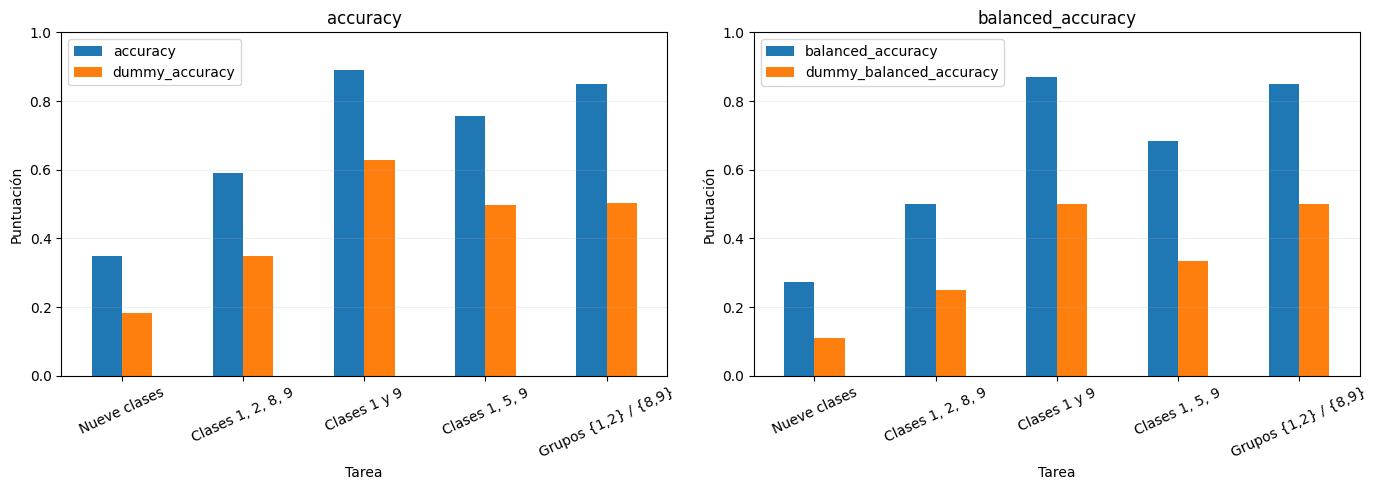

In [6]:
tareas = [
    ('Nueve clases', list(clases), False),
    ('Clases 1, 2, 8, 9', [1, 2, 8, 9], False),
    ('Clases 1 y 9', [1, 9], False),
    ('Clases 1, 5, 9', [1, 5, 9], False),
    ('Grupos {1,2} / {8,9}', [1, 2, 8, 9], True),
]
filas = []; modelos = {}
for nombre, categorias, agrupar in tareas:
    res, modelo, real, pred = evaluar_tarea(categorias, agrupar)
    filas.append({'Tarea': nombre, **res})
    modelos[nombre] = (modelo, real, pred)
resumen = pd.DataFrame(filas).set_index('Tarea')
with pd.option_context('display.max_columns', None):
    display(resumen.round(4))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metrica in zip(axes, ['accuracy', 'balanced_accuracy']):
    resumen[[metrica, 'dummy_'+metrica]].plot.bar(ax=ax, rot=25)
    ax.set(title=metrica, ylim=(0, 1), ylabel='Puntuación')
    ax.grid(axis='y', alpha=.2)
fig.tight_layout()
plt.show()

## 5. Comparación de distancias con las nueve clases
Las tres distancias se aplican a la misma codificación y separación. Su comparación ilustra que KNN admite distancias binarias; no busca declarar una superior por diferencias mínimas en una sola partición.

In [7]:
comparacion = []
base = resumen.loc['Nueve clases'].to_dict()
comparacion.append({'Distancia': 'jaccard', **base})
for distancia in ['hamming', 'euclidean']:
    res, _, _, _ = evaluar_tarea(clases, metrica=distancia)
    comparacion.append({'Distancia': distancia, **res})
display(pd.DataFrame(comparacion).set_index('Distancia')[
    ['accuracy', 'balanced_accuracy', 'f1_macro', 'kappa', 'filas_desconocidas']].round(4))

,accuracy,balanced_accuracy,f1_macro,kappa,filas_desconocidas
Distancia,,,,,
jaccard,0.3476,0.272,0.2503,0.2399,0.0
hamming,0.3476,0.272,0.2503,0.2399,0.0
euclidean,0.3476,0.272,0.2503,0.2399,0.0


## 6. Los 36 pares de categorías
Se ajusta un KNN nuevo para cada par, con el mismo K y la misma política de separación. Esto es un **análisis de tareas binarias independientes**: no se combinan sus votos para construir un clasificador multiclase One-vs-One.

Las matrices muestran todos los pares, no solo los extremos. La diagonal se deja vacía porque no existe clasificación entre una clase y ella misma. Los mapas de accuracy y balanced accuracy usan la misma escala 0–1. Se incluye la referencia mayoritaria y la ganancia frente a ella.

,Clase A,Clase B,accuracy,balanced_accuracy,f1_macro,kappa,dummy_accuracy,dummy_balanced_accuracy,dummy_f1_macro,dummy_kappa,n_train,n_test,n_clases,columnas_binarias,filas_desconocidas,proporcion_mayoritaria_test,ganancia_accuracy
6,1,8,0.8879,0.8847,0.8865,0.7732,0.5398,0.5,0.3506,0.0,1557,767,2,75,0,0.5398,0.3481
7,1,9,0.8892,0.8693,0.8782,0.7570,0.6282,0.5,0.3858,0.0,1339,659,2,75,0,0.6282,0.2610
4,1,6,0.8672,0.8638,0.8625,0.7250,0.5974,0.5,0.3740,0.0,1408,693,2,74,0,0.5974,0.2698
5,1,7,0.8722,0.8586,0.8632,0.7266,0.6152,0.5,0.3809,0.0,1366,673,2,74,0,0.6152,0.2571
20,3,9,0.8131,0.8038,0.8052,0.6105,0.5947,0.5,0.3729,0.0,836,412,2,73,0,0.5947,0.2184
25,4,9,0.8062,0.7995,0.8020,0.6052,0.5457,0.5,0.3530,0.0,912,449,2,72,0,0.5457,0.2606
14,2,9,0.7976,0.7914,0.7917,0.5833,0.5833,0.5,0.3684,0.0,852,420,2,72,0,0.5833,0.2143
2,1,4,0.8123,0.7828,0.7856,0.5713,0.6699,0.5,0.4012,0.0,1255,618,2,74,0,0.6699,0.1424
3,1,5,0.8333,0.7817,0.7920,0.5848,0.7041,0.5,0.4132,0.0,1194,588,2,74,0,0.7041,0.1293
29,5,9,0.7924,0.7658,0.7738,0.5543,0.5847,0.5,0.3690,0.0,851,419,2,73,0,0.5847,0.2076


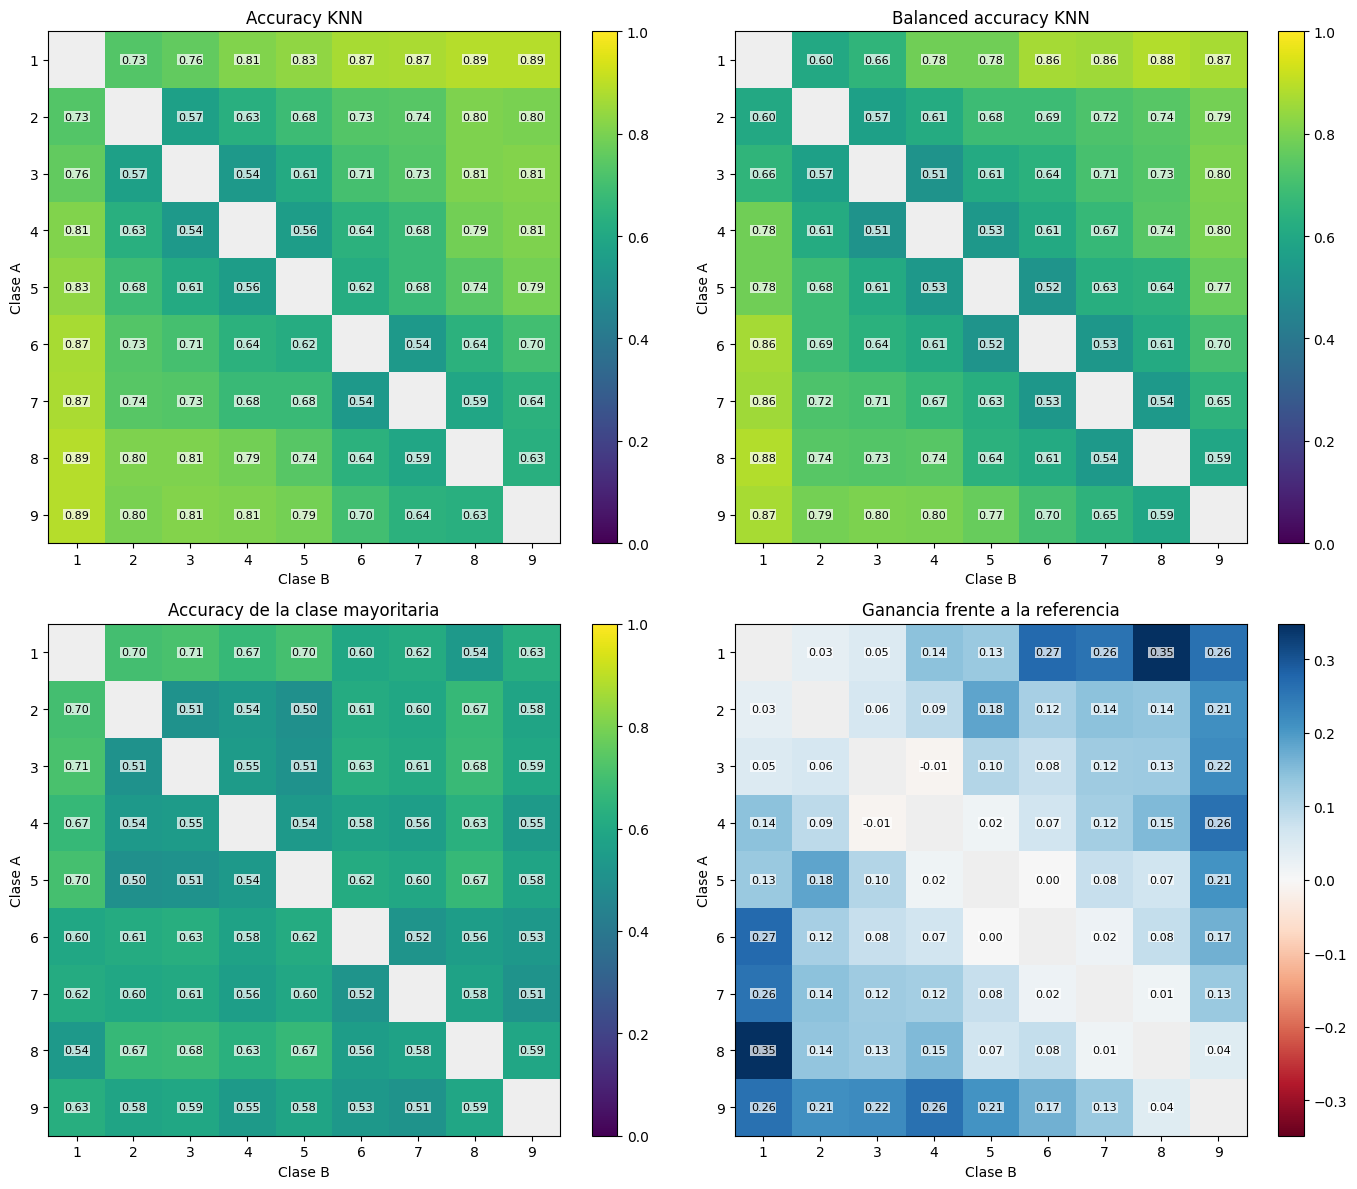

In [8]:
pares = []
for a, b in combinations(clases, 2):
    res, _, _, _ = evaluar_tarea([a, b])
    pares.append({'Clase A': a, 'Clase B': b, **res})
pares = pd.DataFrame(pares)
assert len(pares) == 36
with pd.option_context('display.max_rows', 40, 'display.max_columns', None):
    display(pares.sort_values('balanced_accuracy', ascending=False).round(4))

def matriz_pares(columna):
    matriz = np.full((len(clases), len(clases)), np.nan)
    posiciones = {clase: i for i, clase in enumerate(clases)}
    for _, fila in pares.iterrows():
        i, j = posiciones[fila['Clase A']], posiciones[fila['Clase B']]
        matriz[i, j] = matriz[j, i] = fila[columna]
    return matriz

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, columna, titulo in zip(axes.ravel(),
    ['accuracy', 'balanced_accuracy', 'dummy_accuracy', 'ganancia_accuracy'],
    ['Accuracy KNN', 'Balanced accuracy KNN', 'Accuracy de la clase mayoritaria', 'Ganancia frente a la referencia']):
    matriz = matriz_pares(columna)
    ganancia = columna == 'ganancia_accuracy'
    cmap = plt.get_cmap('RdBu' if ganancia else 'viridis').copy()
    cmap.set_bad('#eeeeee')
    limite = max(.01, float(np.nanmax(np.abs(matriz)))) if ganancia else 1
    im = ax.imshow(matriz, cmap=cmap, vmin=-limite if ganancia else 0, vmax=limite)
    for i in range(len(clases)):
        for j in range(len(clases)):
            if np.isfinite(matriz[i, j]):
                ax.text(j, i, f'{matriz[i,j]:.2f}', ha='center', va='center',
                        fontsize=8, color='black', bbox=dict(facecolor='white', alpha=.7, edgecolor='none', pad=.5))
    ax.set(xticks=range(len(clases)), yticks=range(len(clases)),
           xticklabels=clases, yticklabels=clases, xlabel='Clase B', ylabel='Clase A', title=titulo)
    fig.colorbar(im, ax=ax, fraction=.046)
fig.tight_layout()
plt.show()

## 7. Matrices de confusión y lectura de los resultados
Una matriz normalizada por filas muestra el recall de cada clase en su diagonal. Permite detectar categorías que un accuracy global podría ocultar.

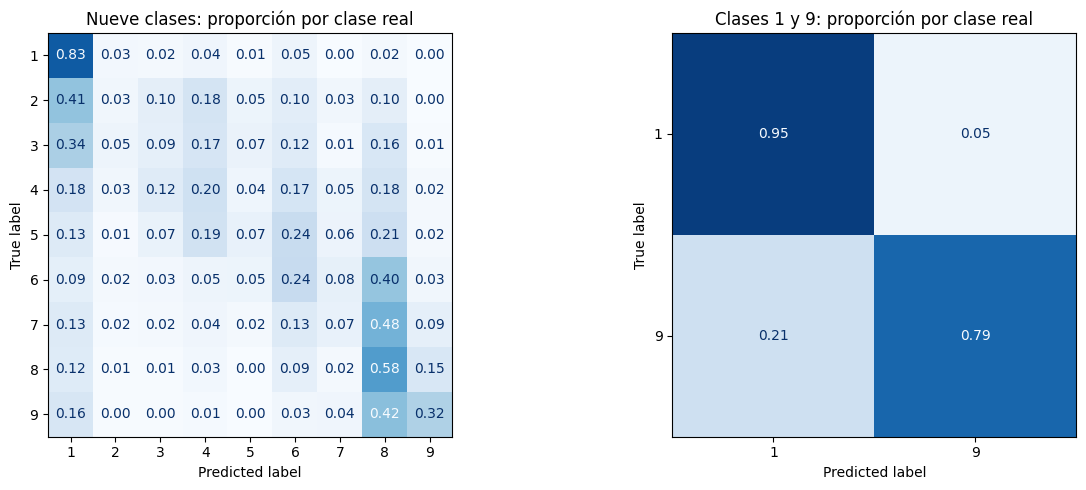

Mejor par observado por balanced accuracy: 1–8, 0.885
Peor par observado por balanced accuracy: 3–4, 0.512
Son extremos observados en esta partición, no garantías para datos futuros.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, nombre in zip(axes, ['Nueve clases', 'Clases 1 y 9']):
    _, real, pred = modelos[nombre]
    ConfusionMatrixDisplay.from_predictions(real, pred, normalize='true',
        values_format='.2f', cmap='Blues', ax=ax, colorbar=False, im_kw={'vmin': 0, 'vmax': 1})
    ax.set_title(nombre + ': proporción por clase real')
fig.tight_layout()
plt.show()

mejor = pares.loc[pares['balanced_accuracy'].idxmax()]
peor = pares.loc[pares['balanced_accuracy'].idxmin()]
print(f"Mejor par observado por balanced accuracy: {int(mejor['Clase A'])}–{int(mejor['Clase B'])}, {mejor['balanced_accuracy']:.3f}")
print(f"Peor par observado por balanced accuracy: {int(peor['Clase A'])}–{int(peor['Clase B'])}, {peor['balanced_accuracy']:.3f}")
print('Son extremos observados en esta partición, no garantías para datos futuros.')

## Conclusiones que sí permite el experimento
- KNN puede clasificar características categóricas codificadas utilizando Jaccard o Hamming. La variable objetivo puede seguir teniendo nueve clases.
- La codificación forma parte de la definición de distancia: omitir indicadores puede cambiar la geometría. One-hot completo trata simétricamente las categorías conocidas de una variable.
- En este diseño, Jaccard, Hamming y Euclidiana pueden ordenar igual los vecinos: no hay que forzar diferencias entre ellas.
- Un mayor accuracy entre dos categorías no demuestra una mejora en la tarea original. Hay menos clases, otra población y posiblemente otro desbalance. El par de extremos no representa necesariamente a todos los pares.
- Agrupar clases cambia qué se considera error: confundir 1 con 2 deja de penalizarse al agruparlas.
- La referencia mayoritaria y balanced accuracy ayudan a interpretar cuánto aporta el modelo. Ni siquiera balanced accuracy hace equivalentes tareas con distinto número de clases.
- Se trata de una comparación descriptiva con una sola partición. Para conclusiones más sólidas, repita con particiones estratificadas o validación cruzada, ajuste el codificador dentro de cada partición y reporte dispersión. Seleccionar el “mejor par” entre 36 usando estas evaluaciones introduce selección; confirme esa conclusión con datos independientes.
- Si se busca el mejor K, hágalo dentro del entrenamiento con validación cruzada; mantenga una prueba final sin utilizarla para elegir K o la codificación.

**Actividad:** compare el par 1–9 con pares vecinos como 1–2 u 8–9. Revise tamaños, desbalance, balanced accuracy y ganancia sobre la referencia antes de afirmar que son más fáciles. No se impone una conclusión que los datos no sustenten.